<a href="https://colab.research.google.com/github/GarzonDiegoINL/Characterization/blob/main/XRD_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Installing specialized XRD and parsing libraries...")
!pip install striprtf xrayutilities lmfit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xrayutilities as xu
print(f"Libraries installed. Xrayutilities version: {xu.__version__}")

Installing specialized XRD and parsing libraries...
Libraries installed. Xrayutilities version: 1.7.12


## Reference Pattern Upload


In [14]:
import io
import pandas as pd
from striprtf.striprtf import rtf_to_text
from google.colab import files

def get_ref_peaks(file_name):
    """Parses an RTF file to extract a peak list DataFrame."""
    with open(file_name, 'r') as infile:
        content = infile.read()
        text = rtf_to_text(content).split('\n')

    peak_list_start_index = None
    peak_list_end_index = None

    for i, line in enumerate(text):
        if line.strip() == 'Peak list':
            peak_list_start_index = i + 2
        if line.strip() in ['Structure', 'Stick Pattern']:
            peak_list_end_index = i - 2
            break

    if peak_list_start_index is not None:
        peak_list_data = text[peak_list_start_index:peak_list_end_index]
        peak_list_string = "\n".join(peak_list_data)
        data_io = io.StringIO(peak_list_string)
        df = pd.read_csv(data_io, sep=r'\s+', skiprows=[0], header=None,
                         names=['No.', 'h', 'k', 'l', 'd [A]', '2Theta[deg]', 'I [%]'])
        return df
    else:
        print(f"Warning: Peak list not found in {file_name}")
        return pd.DataFrame()

print("Please upload your reference RTF files:")
uploaded_refs = files.upload()

references_dict = {}
for fn in uploaded_refs.keys():
    ref_name = fn.replace('.rtf', '')
    references_dict[ref_name] = get_ref_peaks(fn)
    print(f"Processed reference: {ref_name}")

# Display keys to confirm
print(f"References loaded: {list(references_dict.keys())}")

Please upload your reference RTF files:


Saving 01-088-884 Bi S I.rtf to 01-088-884 Bi S I.rtf
Processed reference: 01-088-884 Bi S I
References loaded: ['01-088-884 Bi S I']


## Experimental Pattern Upload

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
from scipy.optimize import curve_fit
from google.colab import files

def normalize_data(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

def polynomial_background(x, *coeffs):
    return np.polyval(coeffs, x)

def background_fit(x_values, y_values, background_regions, poly_degree=3):
    x_bg, y_bg = [], []
    for start, end in background_regions:
        mask = (x_values >= start) & (x_values <= end)
        x_bg.extend(x_values[mask])
        y_bg.extend(y_values[mask])

    coeffs = np.polyfit(x_bg, y_bg, poly_degree)
    fitted_bg = np.polyval(coeffs, x_values)
    return x_values, normalize_data(y_values - fitted_bg)

def get_exp_data(file_name, r_range=[10, 60]):
    xf = xu.io.XRDMLFile(file_name)
    x = xf.scan.ddict['2Theta']
    y = xf.scan.ddict['detector'] * xf.scan.ddict['countTime'][0]
    mask = (x > r_range[0]) & (x < r_range[1])
    return x[mask], xu.math.functions.kill_spike(y[mask])

print("Please upload your experimental .xrdml files:")
uploaded_exp = files.upload()

samples_dict = {}
for fn in uploaded_exp.keys():
    x, y = get_exp_data(fn)
    # Default background regions for initial processing
    bg_regions = [(10, 12), (25, 27), (45, 50)]
    _, y_corr = background_fit(x, y, bg_regions)
    samples_dict[fn.replace('.xrdml', '')] = {'x': x, 'y': y_corr}
    print(f"Processed sample: {fn}")

Please upload your experimental .xrdml files:


Saving 260609A1 BiSI GI0.3.xrdml to 260609A1 BiSI GI0.3.xrdml
Saving 260609A2 BiSI GI0.3.xrdml to 260609A2 BiSI GI0.3.xrdml
Saving 260609A3 BiSI GI0.3.xrdml to 260609A3 BiSI GI0.3.xrdml
Saving 260609A4 BiSI GI0.3.xrdml to 260609A4 BiSI GI0.3.xrdml
Saving 260609A5 BiSI GI0.3.xrdml to 260609A5 BiSI GI0.3.xrdml
Processed sample: 260609A1 BiSI GI0.3.xrdml
Processed sample: 260609A2 BiSI GI0.3.xrdml
Processed sample: 260609A3 BiSI GI0.3.xrdml
Processed sample: 260609A4 BiSI GI0.3.xrdml
Processed sample: 260609A5 BiSI GI0.3.xrdml


## Generalized Analysis

Match peaks with references, calculate crystallite size and texture coefficient

In [16]:
from scipy.signal import find_peaks, savgol_filter
from lmfit.models import PseudoVoigtModel, ConstantModel
import pandas as pd
import numpy as np

def find_and_fit_peaks(x, y, sample_name, min_rel_height=0.05, peak_prominence=0.05):
    # Smooth data for better peak detection
    y_smooth = savgol_filter(y, window_length=11, polyorder=3)

    # Detect peaks
    height_threshold = min_rel_height * np.max(y_smooth)
    prom_threshold = peak_prominence * np.max(y_smooth)
    peaks_idx, _ = find_peaks(y_smooth, height=height_threshold, prominence=prom_threshold)

    results = []
    for idx in peaks_idx:
        # Define a local window for fitting (approx +/- 1 degree)
        window = 40
        left, right = max(0, idx - window), min(len(x)-1, idx + window)
        xx, yy = x[left:right+1], y[left:right+1]

        # Setup Pseudo-Voigt model
        model = PseudoVoigtModel() + ConstantModel()
        params = model.make_params(center=x[idx], amplitude=y[idx]*0.1, sigma=0.1, c=np.min(yy))

        try:
            out = model.fit(yy, params, x=xx)
            res = {
                'center': out.params['center'].value,
                'fwhm': out.params['fwhm'].value,
                'height': out.params['amplitude'].value / (out.params['sigma'].value * np.sqrt(2*np.pi)), # Approx height
                'amplitude': out.params['amplitude'].value
            }
            if 0 < res['fwhm'] < 2: # Filter unrealistic fits
                results.append(res)
        except:
            continue

    df_peaks = pd.DataFrame(results)
    return df_peaks

print("Detecting and fitting peaks for all samples...")
for sample_name in samples_dict:
    x_data = samples_dict[sample_name]['x']
    y_data = samples_dict[sample_name]['y']
    samples_dict[sample_name]['peak_df'] = find_and_fit_peaks(x_data, y_data, sample_name)
    print(f"Found {len(samples_dict[sample_name]['peak_df'])} peaks in {sample_name}")

# Display example peak table
if samples_dict:
    first_sample = list(samples_dict.keys())[0]
    print(f"\nPeak data for {first_sample}:")
    display(samples_dict[first_sample]['peak_df'].head())

Detecting and fitting peaks for all samples...
Found 16 peaks in 260609A1 BiSI GI0.3
Found 13 peaks in 260609A2 BiSI GI0.3
Found 14 peaks in 260609A3 BiSI GI0.3
Found 13 peaks in 260609A4 BiSI GI0.3
Found 12 peaks in 260609A5 BiSI GI0.3

Peak data for 260609A1 BiSI GI0.3:


,center,fwhm,height,amplitude
0,13.502683,0.522636,0.073434,0.048101
1,20.251459,0.530809,0.308834,0.205458
2,22.643898,0.622011,0.173642,0.135367
3,25.308580,0.486278,0.042485,0.025893
4,27.261675,0.538948,0.049897,0.033704


In [17]:
import numpy as np
import pandas as pd

def calculate_scherrer(fwhm_deg, theta_deg, K=0.9, wavelength=1.5406):
    """Calculates crystallite size (nm) using Scherrer equation."""
    beta = np.deg2rad(fwhm_deg)
    theta = np.deg2rad(theta_deg / 2)
    return (K * wavelength) / (beta * np.cos(theta)) if beta > 0 else np.nan

def match_and_analyze(samples_dict, references_dict, tolerance=0.3):
    """Matches peaks, calculates TC and crystallite size."""
    all_results = []

    # Use the first reference for matching logic (assuming primary phase)
    ref_name = list(references_dict.keys())[0]
    ref_df = references_dict[ref_name].sort_values('2Theta[deg]')

    for sample_name, data in samples_dict.items():
        exp_peaks = data['peak_df'].sort_values('center')

        # Merge experimental peaks with reference peaks within tolerance
        matched = pd.merge_asof(
            exp_peaks,
            ref_df.rename(columns={'2Theta[deg]': 'center'}),
            on='center',
            tolerance=tolerance,
            direction='nearest'
        ).dropna(subset=['No.'])

        # Calculate Crystallite Size
        matched['crystallite_size'] = matched.apply(
            lambda row: calculate_scherrer(row['fwhm'], row['center']), axis=1
        )

        # Calculate Texture Coefficient (TC)
        # Ri = I_exp / I_ref_theoretical
        matched['Ri'] = matched['height'] / matched['I [%]']
        avg_Ri = matched['Ri'].mean()
        matched['TC'] = matched['Ri'] / avg_Ri if avg_Ri > 0 else np.nan

        # Store matched data back to dict
        samples_dict[sample_name]['analysis_df'] = matched

        # Aggregate summary metrics
        summary = {
            'Sample': sample_name,
            'Avg_Crystallite_Size_nm': matched['crystallite_size'].mean(),
            'Max_TC': matched['TC'].max(),
            'Preferred_hkl': matched.loc[matched['TC'].idxmax(), ['h','k','l']].tolist() if not matched.empty else None
        }
        all_results.append(summary)

    return pd.DataFrame(all_results)

print("Matching experimental peaks with reference data and calculating crystallographic metrics...")
final_analysis_df = match_and_analyze(samples_dict, references_dict)

# Display the analysis results
print("\nSummary Analysis Results (Scherrer Size & Texture):")
display(final_analysis_df)

# Save analysis to CSV
final_analysis_df.to_csv('xrd_analysis_summary.csv', index=False)
print("Analysis summary saved to 'xrd_analysis_summary.csv'.")

Matching experimental peaks with reference data and calculating crystallographic metrics...

Summary Analysis Results (Scherrer Size & Texture):


,Sample,Avg_Crystallite_Size_nm,Max_TC,Preferred_hkl
0,260609A1 BiSI GI0.3,141.002541,1.885513,"[1.0, 0.0, 5.0]"
1,260609A2 BiSI GI0.3,163.914718,1.573574,"[1.0, 1.0, 2.0]"
2,260609A3 BiSI GI0.3,154.247041,1.595631,"[1.0, 1.0, 2.0]"
3,260609A4 BiSI GI0.3,146.058608,1.513361,"[1.0, 1.0, 2.0]"
4,260609A5 BiSI GI0.3,149.544589,1.744186,"[0.0, 2.0, 0.0]"


Analysis summary saved to 'xrd_analysis_summary.csv'.


## Stacked Plot


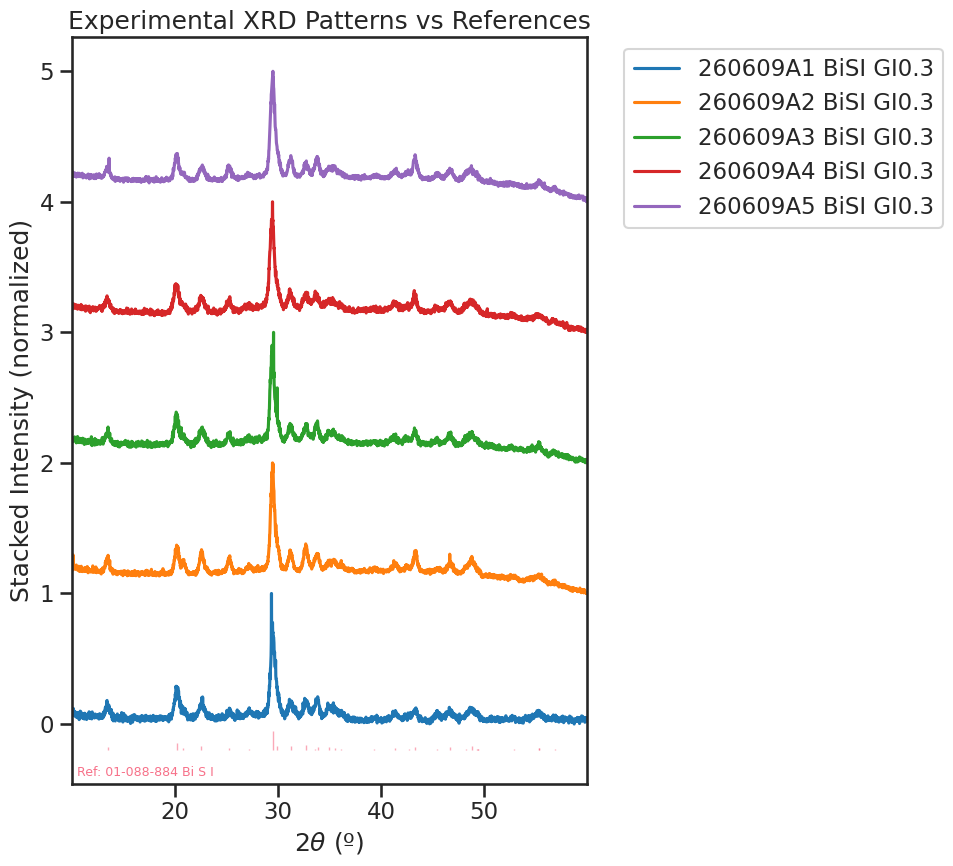

In [18]:
import seaborn as sns
import plotly.graph_objects as go

def plot_stacked_xrd(samples_dict, references_dict, reference_peak_scale=0.15):
    sns.set_style('ticks')
    fig, ax = plt.subplots(figsize=(10, len(samples_dict) + 4))
    sample_names = sorted(samples_dict.keys())

    min_x_value = 10
    max_x_value = 80

    for idx, name in enumerate(sample_names):
        x, y = samples_dict[name]['x'], samples_dict[name]['y']
        ax.plot(x, y + idx, label=name)
        min_x_value = max(min_x_value, np.min(x))
        max_x_value = min(max_x_value, np.max(x))

    colors = sns.color_palette('husl', len(references_dict))
    for i, (ref_name, ref_df) in enumerate(references_dict.items()):
        if not ref_df.empty:
            max_int = ref_df['I [%]'].max()
            for _, row in ref_df.iterrows():
                ax.vlines(row['2Theta[deg]'], -0.2, (row['I [%]']/max_int)*reference_peak_scale - 0.2,
                          color=colors[i], alpha=0.6, linewidth=1)
            ax.text(10.5, -0.4 - (i*0.2), f"Ref: {ref_name}", color=colors[i], fontsize=9)

    ax.set_xlim([min_x_value, max_x_value])
    ax.set_xlabel('2$\\theta$ (º)')
    ax.set_ylabel('Stacked Intensity (normalized)')
    ax.set_title('Experimental XRD Patterns vs References')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('stacked_xrd.png', dpi=300)
    plt.show()

def plot_stacked_xrd_plotly(samples_dict, references_dict, reference_peak_scale=0.2):
    fig = go.Figure()
    sample_names = sorted(samples_dict.keys())

    min_x_value = 10
    max_x_value = 80

    for idx, name in enumerate(sample_names):
        x, y = samples_dict[name]['x'], samples_dict[name]['y']
        fig.add_trace(go.Scatter(x=x, y=y + idx, name=name, mode='lines'))
        min_x_value = max(min_x_value, np.min(x))
        max_x_value = min(max_x_value, np.max(x))

    for ref_name, ref_df in references_dict.items():
        if not ref_df.empty:
            max_int = ref_df['I [%]'].max()
            for _, row in ref_df.iterrows():
                fig.add_trace(go.Scatter(x=[row['2Theta[deg]'], row['2Theta[deg]']],
                                         y=[0, (row['I [%]']/max_int)*reference_peak_scale],
                                         mode='lines', line=dict(width=1),
                                         name=f"Ref: {ref_name}", showlegend=False))

    fig.update_layout(title='Interactive Stacked XRD', xaxis_title='2Theta', yaxis_title='Intensity + Offset', xaxis_range=[min_x_value, max_x_value])
    fig.show()

# Execute plotting
plot_stacked_xrd(samples_dict, references_dict)
plot_stacked_xrd_plotly(samples_dict, references_dict)

## Single Pattern Plot

In [19]:
def plot_single_pattern(samples_dict, references_dict, sample_name, show_fitted_peaks=True, show_reference_peaks=True, reference_peak_scale=0.15):
    """Plots a single XRD pattern with optional fitted and reference peaks."""
    sns.set_context('talk')
    fig, ax = plt.subplots(figsize=(12, 6))

    if sample_name not in samples_dict:
        print(f"Sample '{sample_name}' not found.")
        return

    x, y = samples_dict[sample_name]['x'], samples_dict[sample_name]['y']
    ax.plot(x, y, label=f'Experimental: {sample_name}', color='blue')

    min_x_value = np.min(x)
    max_x_value = np.max(x)
    ax.set_xlim([min_x_value, max_x_value])

    if show_fitted_peaks and 'peak_df' in samples_dict[sample_name]:
        peak_df = samples_dict[sample_name]['peak_df']
        for _, row in peak_df.iterrows():
            ax.vlines(row['center'], 0, row['height'], color='red', linestyle='--', alpha=0.7, label='_Fitted Peak')
            # Annotate peak positions
            ax.text(row['center'], row['height'] * 1.05, f'{row['center']:.2f}',
                    rotation=90, va='bottom', ha='center', fontsize=8, color='red')

    if show_reference_peaks and references_dict:
        colors = sns.color_palette('husl', len(references_dict))
        for i, (ref_name, ref_df) in enumerate(references_dict.items()):
            if not ref_df.empty:
                max_int = ref_df['I [%]'].max()
                for _, row in ref_df.iterrows():
                    ax.vlines(row['2Theta[deg]'], -0.05, (row['I [%]']/max_int)*reference_peak_scale - 0.05,
                              color=colors[i], alpha=0.6, linewidth=1)
                ax.text(10.5, -0.1 - (i*0.1), f"Ref: {ref_name}", color=colors[i], fontsize=9)

    ax.set_xlabel('2$\theta$ (º)')
    ax.set_ylabel('Intensity (normalized)')
    ax.set_title(f'XRD Pattern for {sample_name}')
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles)) # Remove duplicate labels for fitted peaks
    ax.legend(unique_labels.values(), unique_labels.keys(), loc='upper right')
    plt.tight_layout()
    plt.savefig(f'single_xrd_{sample_name.replace(' ', '_')}.png', dpi=300)
    plt.show()

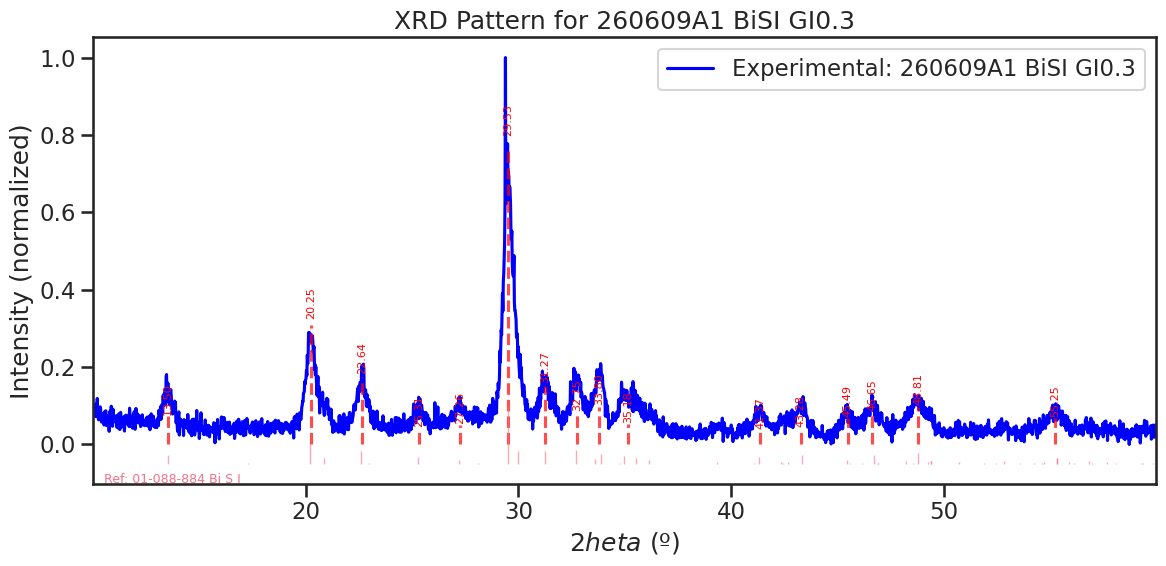

In [20]:
# Choose a sample to plot
example_sample = list(samples_dict.keys())[0]
plot_single_pattern(samples_dict, references_dict, example_sample, show_fitted_peaks=True, show_reference_peaks=True)

Next, let's visualize the Texture Coefficient (TC) and Crystallite Size for the identified peaks within a chosen sample. This will help us understand the microstructural properties at a peak-specific level.

## Interactive TC Plot for All Samples

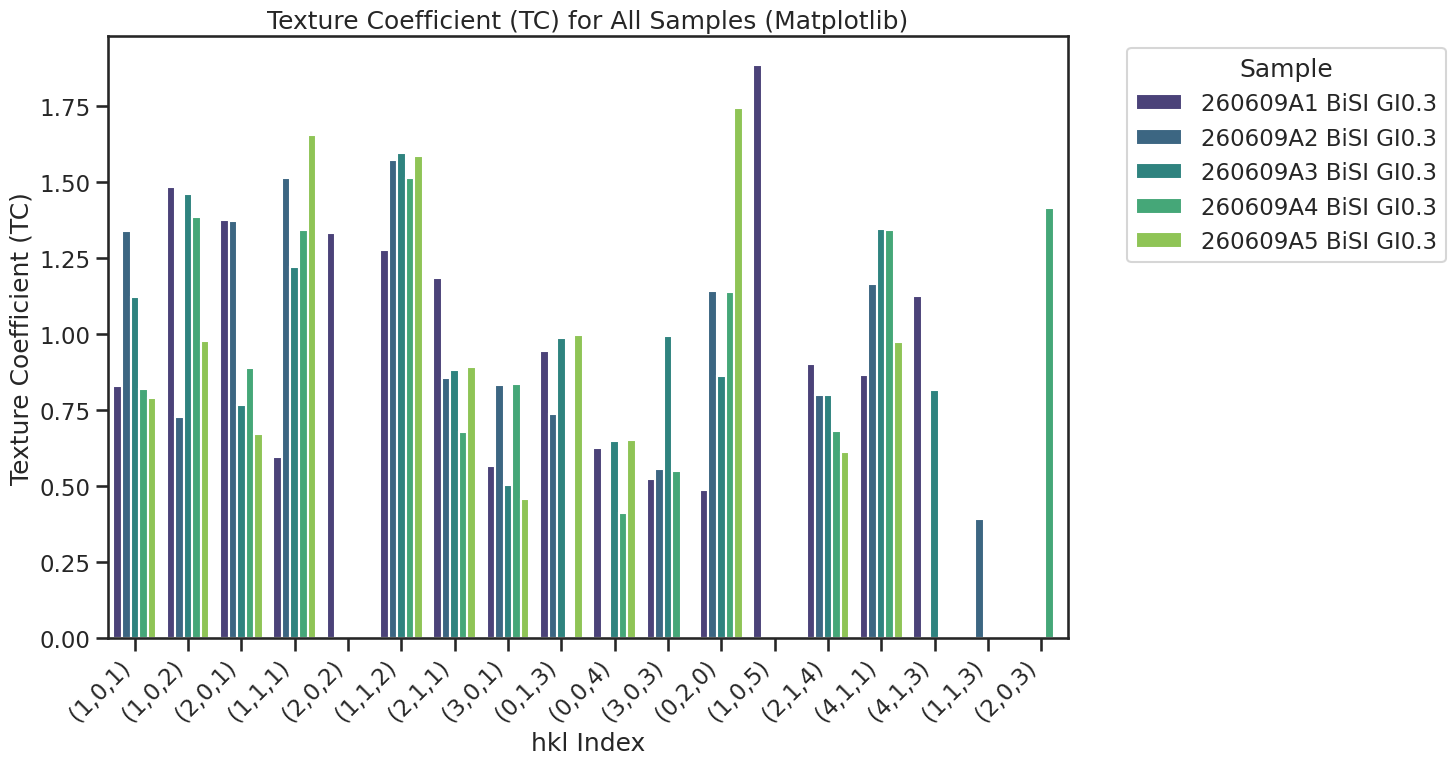

In [25]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_all_tc_interactive(samples_dict):
    all_analysis_data = []
    for sample_name, data in samples_dict.items():
        if 'analysis_df' in data and not data['analysis_df'].empty:
            df = data['analysis_df'].copy()
            df['Sample'] = sample_name
            df['hkl'] = df.apply(lambda row: f"({int(row['h'])},{int(row['k'])},{int(row['l'])})", axis=1)
            all_analysis_data.append(df)

    if not all_analysis_data:
        print("No analysis data available to plot TC.")
        return

    combined_df = pd.concat(all_analysis_data, ignore_index=True)

    fig = px.bar(combined_df, x='hkl', y='TC', color='Sample',
                 barmode='group', title='Interactive Texture Coefficient (TC) for All Samples')
    fig.update_layout(xaxis_title='hkl Index', yaxis_title='Texture Coefficient (TC)')
    fig.show()

def plot_all_tc_matplotlib(samples_dict):
    all_analysis_data = []
    for sample_name, data in samples_dict.items():
        if 'analysis_df' in data and not data['analysis_df'].empty:
            df = data['analysis_df'].copy()
            df['Sample'] = sample_name
            df['hkl'] = df.apply(lambda row: f"({int(row['h'])},{int(row['k'])},{int(row['l'])})", axis=1)
            all_analysis_data.append(df)

    if not all_analysis_data:
        print("No analysis data available to plot TC for Matplotlib.")
        return

    combined_df = pd.concat(all_analysis_data, ignore_index=True)

    plt.figure(figsize=(15, 8))
    sns.barplot(x='hkl', y='TC', hue='Sample', data=combined_df, palette='viridis')
    plt.title('Texture Coefficient (TC) for All Samples')
    plt.xlabel('hkl Index')
    plt.ylabel('Texture Coefficient (TC)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('all_samples_tc_matplotlib.png', dpi=300)
    plt.show()

plot_all_tc_interactive(samples_dict)
plot_all_tc_matplotlib(samples_dict)

## Interactive Crystallite Size Plot for All Samples

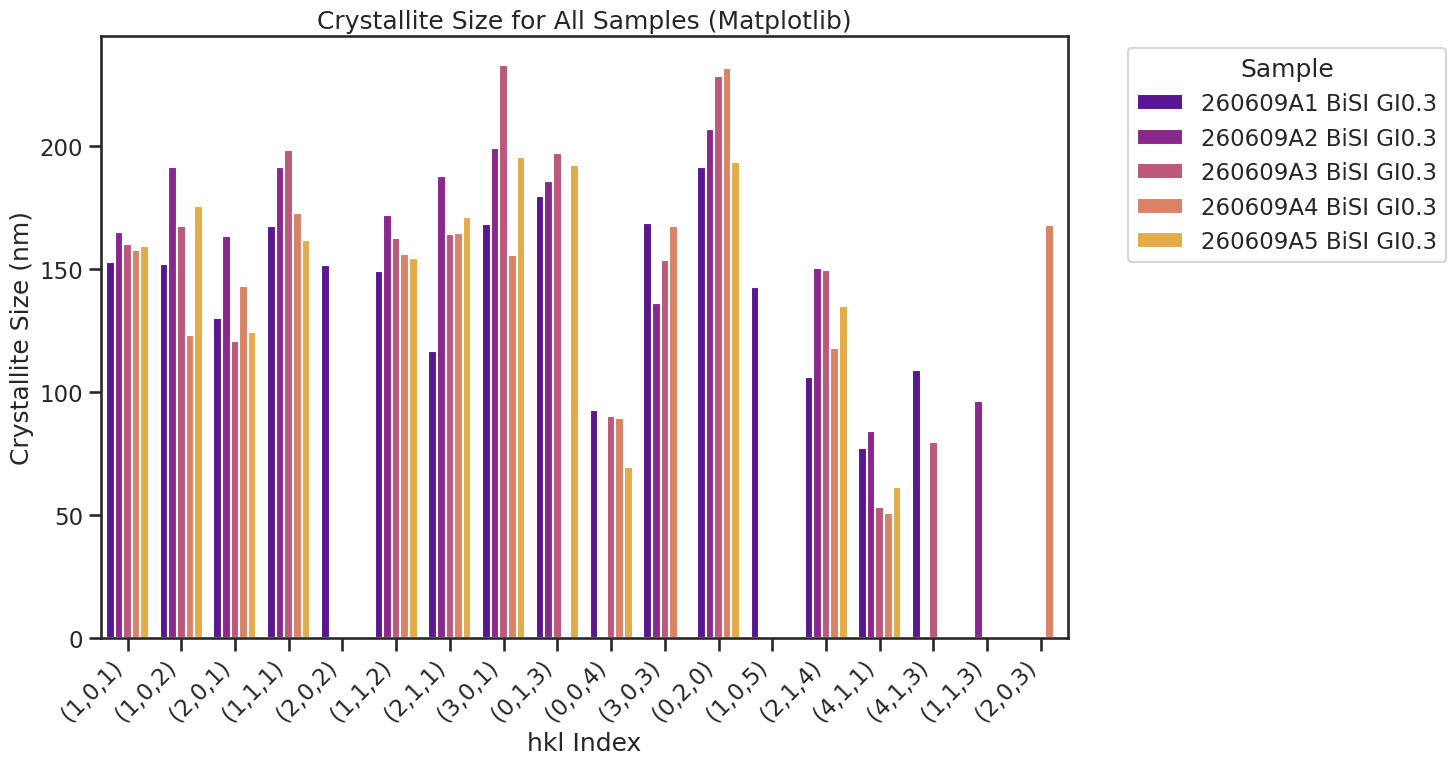

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px

def plot_all_crystallite_size_interactive(samples_dict):
    all_analysis_data = []
    for sample_name, data in samples_dict.items():
        if 'analysis_df' in data and not data['analysis_df'].empty:
            df = data['analysis_df'].copy()
            df['Sample'] = sample_name
            df['hkl'] = df.apply(lambda row: f"({int(row['h'])},{int(row['k'])},{int(row['l'])})", axis=1)
            all_analysis_data.append(df)

    if not all_analysis_data:
        print("No analysis data available to plot Crystallite Size.")
        return

    combined_df = pd.concat(all_analysis_data, ignore_index=True)

    fig = px.bar(combined_df, x='hkl', y='crystallite_size', color='Sample',
                 barmode='group', title='Interactive Crystallite Size for All Samples')
    fig.update_layout(xaxis_title='hkl Index', yaxis_title='Crystallite Size (nm)')
    fig.show()

def plot_all_crystallite_size_matplotlib(samples_dict):
    all_analysis_data = []
    for sample_name, data in samples_dict.items():
        if 'analysis_df' in data and not data['analysis_df'].empty:
            df = data['analysis_df'].copy()
            df['Sample'] = sample_name
            df['hkl'] = df.apply(lambda row: f"({int(row['h'])},{int(row['k'])},{int(row['l'])})", axis=1)
            all_analysis_data.append(df)

    if not all_analysis_data:
        print("No analysis data available to plot Crystallite Size for Matplotlib.")
        return

    combined_df = pd.concat(all_analysis_data, ignore_index=True)

    plt.figure(figsize=(15, 8))
    sns.barplot(x='hkl', y='crystallite_size', hue='Sample', data=combined_df, palette='plasma')
    plt.title('Crystallite Size for All Samples (Matplotlib)')
    plt.xlabel('hkl Index')
    plt.ylabel('Crystallite Size (nm)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('all_samples_crystallite_size_matplotlib.png', dpi=300)
    plt.show()

plot_all_crystallite_size_interactive(samples_dict)
plot_all_crystallite_size_matplotlib(samples_dict)

##Data Export

In [27]:
import pandas as pd
import numpy as np
import os

# 1. Feature Aggregation for PCA
pca_data = []
for sample_name, data in samples_dict.items():
    analysis = data['analysis_df']
    # Flatten relevant metrics into a row
    row = {'Sample': sample_name}
    for _, p in analysis.iterrows():
        row[f"Peak_{int(p['No.'])}_TC"] = p['TC']
        row[f"Peak_{int(p['No.'])}_Size"] = p['crystallite_size']
    pca_data.append(row)

df_features = pd.DataFrame(pca_data).set_index('Sample').fillna(0)

# 4. Result Export and Archiving
df_features.to_excel('full_xrd_features.xlsx')
!zip -r xrd_results_archive.zip *.png *.csv *.xlsx

print("\nPipeline Complete: Data exported, and results archived in 'xrd_results_archive.zip'.")

updating: single_xrd_260609A1_BiSI_GI0.3.png (deflated 13%)
updating: stacked_xrd.png (deflated 12%)
updating: xrd_analysis_summary.csv (deflated 46%)
updating: full_xrd_features.xlsx (deflated 8%)
  adding: all_samples_crystallite_size_matplotlib.png (deflated 25%)
  adding: all_samples_tc_matplotlib.png (deflated 24%)

Pipeline Complete: Data exported, and results archived in 'xrd_results_archive.zip'.
